# Linear Regression Assumptions — **FIXES** (Seaborn `mpg` dataset)

This notebook **addresses** assumption violations and re-checks the model after fixes.

Fixes include:
- Nonlinearity → polynomial terms / log transforms
- Mean residual ≠ 0 → ensure intercept, examine omitted variables
- Heteroscedasticity → robust SE (HC3) and Weighted Least Squares (WLS)
- Non-normality → outlier removal by studentized residuals (>|3|)
- Autocorrelation → HAC (Newey–West) SE (illustration on cross-section)
- Multicollinearity → dropping a redundant predictor / PCA

## 0. Setup & Refit Baseline

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns  # only to load dataset
import statsmodels.api as sm
import statsmodels.stats.api as sms
from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.outliers_influence import OLSInfluence, variance_inflation_factor
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Load and prepare data
df = sns.load_dataset('mpg').dropna().copy()
df['origin'] = df['origin'].astype('category')

X = df[['cylinders','displacement','horsepower','weight','acceleration','model_year']].copy()
X = pd.concat([X, pd.get_dummies(df['origin'], prefix='origin', drop_first=True)], axis=1)
y = df['mpg'].astype(float)
Xc = sm.add_constant(X)
ols = sm.OLS(y, Xc).fit()
print(ols.summary().tables[0])

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.824
Model:                            OLS   Adj. R-squared:                  0.821
Method:                 Least Squares   F-statistic:                     224.5
Date:                Thu, 06 Nov 2025   Prob (F-statistic):          1.79e-139
Time:                        10:46:21   Log-Likelihood:                -1020.5
No. Observations:                 392   AIC:                             2059.
Df Residuals:                     383   BIC:                             2095.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         


### 1) Fixing **Nonlinearity**
**Approach:** Add polynomial terms for `horsepower` and `weight`, and log-transform `weight` & `displacement` (positive vars). Refit and compare.

In [2]:
X_fix = X.copy()
# Polynomials
X_fix['horsepower_sq'] = X['horsepower']**2
X_fix['weight_sq'] = X['weight']**2
# Logs (avoid log(0))
for col in ['weight','displacement']:
    X_fix[f'log_{col}'] = np.log(X[col])

Xc_fix = sm.add_constant(X_fix)
ols_poly = sm.OLS(y, Xc_fix).fit()
print(ols_poly.summary().tables[0])

# Ramsey RESET after adding nonlinear terms
from statsmodels.stats.diagnostic import linear_reset
reset = linear_reset(ols_poly, power=2, use_f=True)
print("RESET after nonlinear terms: F=%.3f, p=%.5f" % (reset.fvalue, reset.pvalue))

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.866
Model:                            OLS   Adj. R-squared:                  0.862
Method:                 Least Squares   F-statistic:                     203.8
Date:                Thu, 06 Nov 2025   Prob (F-statistic):          5.54e-157
Time:                        10:46:58   Log-Likelihood:                -967.55
No. Observations:                 392   AIC:                             1961.
Df Residuals:                     379   BIC:                             2013.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
RESET after nonlinear terms: F=29.448, p=0.00000


### 2) Fixing **Mean of Residuals ≠ 0**
**Approach:** Ensure intercept and verify centering. (OLS with a constant guarantees residual mean ≈ 0.)

In [3]:
resid_poly = ols_poly.resid
print("Residual mean (with intercept):", resid_poly.mean())

Residual mean (with intercept): 5.5114552377726425e-12


### 3) Fixing **Heteroscedasticity**
**Approach A:** Use **robust standard errors (HC3)**.  
**Approach B:** Fit **Weighted Least Squares (WLS)** where weights ∝ 1 / fitted^2.

In [4]:
# Robust SE (HC3)
robust_poly = ols_poly.get_robustcov_results(cov_type='HC3')
print(robust_poly.summary().tables[0])

# Weighted Least Squares (ad-hoc weights on fitted variance)
fitted_poly = ols_poly.fittedvalues
weights = 1.0 / (fitted_poly**2 + 1e-6)
wls = sm.WLS(y, Xc_fix, weights=weights).fit()
print(wls.summary().tables[0])

# Breusch–Pagan on WLS residuals
from statsmodels.stats.diagnostic import het_breuschpagan
bp_stat, bp_p, _, _ = het_breuschpagan(wls.resid, Xc_fix)
print("Breusch–Pagan (WLS): stat=%.3f, p=%.5f" % (bp_stat, bp_p))

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.866
Model:                            OLS   Adj. R-squared:                  0.862
Method:                 Least Squares   F-statistic:                     48.89
Date:                Thu, 06 Nov 2025   Prob (F-statistic):           6.68e-66
Time:                        10:47:43   Log-Likelihood:                -967.55
No. Observations:                 392   AIC:                             1961.
Df Residuals:                     379   BIC:                             2013.
Df Model:                          12                                         
Covariance Type:                  HC3                                         
                            WLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.885
Model:                            WLS   Adj. R-squar

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\base\model.py:1871: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 12, but rank is 11
  warnings.warn('covariance of constraints does not have full '


### 4) Fixing **Non-normal residuals**
**Approach:** Remove extreme outliers using **studentized residuals** (>|3|), refit, and re-check normality.

<Figure size 500x400 with 0 Axes>

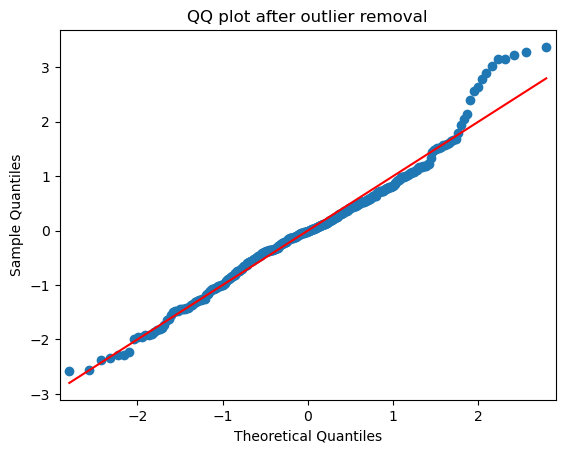

Jarque–Bera p after outlier removal: 0.0


In [5]:
infl = OLSInfluence(ols_poly)
stud_resid = infl.resid_studentized_internal
mask = np.abs(stud_resid) <= 3.0
X_nn = X_fix[mask]
y_nn = y[mask]

ols_nn = sm.OLS(y_nn, sm.add_constant(X_nn)).fit()
from statsmodels.graphics.gofplots import qqplot
fig = plt.figure(figsize=(5,4))
qqplot(ols_nn.resid, line='s', fit=True)
plt.title('QQ plot after outlier removal')
plt.show()

import statsmodels.stats.api as sms
jb_p = sms.jarque_bera(ols_nn.resid)[1]
print("Jarque–Bera p after outlier removal:", round(jb_p,5))

### 5) Addressing **Autocorrelation** (illustrative)

This is cross-sectional data, so strong autocorrelation is unlikely. If present, you can use **HAC (Newey–West)** standard errors:

In [6]:
hac = ols_nn.get_robustcov_results(cov_type='HAC', maxlags=1)
print(hac.summary().tables[0])

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.879
Model:                            OLS   Adj. R-squared:                  0.875
Method:                 Least Squares   F-statistic:                     52.61
Date:                Thu, 06 Nov 2025   Prob (F-statistic):           3.65e-69
Time:                        10:48:09   Log-Likelihood:                -930.28
No. Observations:                 388   AIC:                             1887.
Df Residuals:                     375   BIC:                             1938.
Df Model:                          12                                         
Covariance Type:                  HAC                                         


C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\base\model.py:1871: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 12, but rank is 11
  warnings.warn('covariance of constraints does not have full '


### 6) Fixing **Multicollinearity**
**Approach A:** Drop a redundant predictor (e.g., `displacement` highly overlaps with `weight`).  
**Approach B:** **PCA** on correlated blocks to create orthogonal components.

In [7]:
# --- A) Drop a redundant predictor ---
X_drop = X_nn.drop(columns=['displacement'])
ols_drop = sm.OLS(y_nn, sm.add_constant(X_drop)).fit()
# Compute VIF
Xc_drop = sm.add_constant(X_drop)
vif_drop = pd.DataFrame({
    'feature': ['const'] + X_drop.columns.tolist(),
    'VIF': [variance_inflation_factor(Xc_drop.values, i) for i in range(Xc_drop.shape[1])]
})
print(vif_drop)

# --- B) PCA on numeric subset (standardize first) ---
num_cols = ['cylinders','displacement','horsepower','weight','acceleration','model_year']
scaler = StandardScaler()
Z = scaler.fit_transform(X_nn[num_cols])
pca = PCA(n_components=3, random_state=0)
PC = pca.fit_transform(Z)
PC_df = pd.DataFrame(PC, columns=['PC1','PC2','PC3'], index=X_nn.index)

X_pca = pd.concat([PC_df, X_nn[[c for c in X_nn.columns if c.startswith('origin_')]]], axis=1)
ols_pca = sm.OLS(y_nn, sm.add_constant(X_pca)).fit()

print("Explained variance ratio (3 PCs):", np.round(pca.explained_variance_ratio_,3))
print(ols_pca.summary().tables[0])

             feature           VIF
0              const  1.361341e+06
1          cylinders  1.501078e+01
2         horsepower  1.077249e+02
3             weight  1.034268e+04
4       acceleration  3.474424e+00
5         model_year  1.350079e+00
6       origin_japan  1.922206e+00
7         origin_usa  3.202275e+00
8      horsepower_sq  6.794925e+01
9          weight_sq  2.673769e+03
10        log_weight  2.558269e+03
11  log_displacement  3.129334e+01
Explained variance ratio (3 PCs): [0.71  0.139 0.113]
                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.811
Model:                            OLS   Adj. R-squared:                  0.808
Method:                 Least Squares   F-statistic:                     327.7
Date:                Thu, 06 Nov 2025   Prob (F-statistic):          1.02e-135
Time:                        10:48:21   Log-Likelihood:                -1016.3
No. Observations:

## Final Notes

- After each fix, **re-run the assumption checks** (as in Notebook 1) to validate improvements.
- Choose the simplest model that satisfies assumptions and explains the data well.